In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import math

Q1. Consider the following undirected social network: V={A,B,C,D,E,F,G,H}  E={(A,B),(A,C),(B,C),(B,D),(C,D),(D,E),(D,F),(E,F),(E,G),(F,G),(G,H)} Using this network, calculate and compare the importance of each node using Degree Centrality, Closeness Centrality, Betweenness Centrality, and Eigenvector Centrality. 1. Calculate the degree centrality of each node and identify the node with the maximum number of direct connections. 2. Calculate the closeness centrality of each node using shortest-path distances and identify the node that can reach other nodes most efficiently. 3. Calculate the betweenness centrality and identify the node that acts as the most important bridge between different parts of the network. 4. Calculate the eigenvector centrality and identify the node that is connected to the most influential nodes. 5. Compare the rankings obtained from all four centrality measures. Determine whether the same node is considered most important by all measures and explain why different centrality measures may identify different nodes as important.

In [13]:
G = nx.Graph()

E = [("A","B"), ("A","C"), ("B","C"), ("B","D"),("C","D"), ("D","E"), ("D","F"), ("E","F"),("E","G"), ("F","G"), ("G","H")]

G.add_edges_from(E)

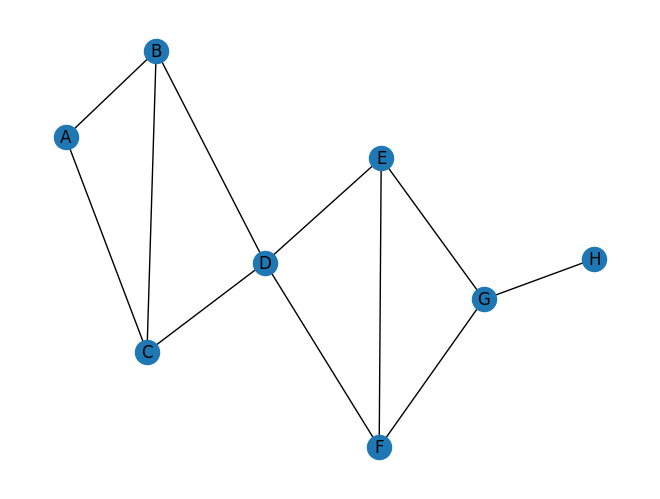

In [14]:
nx.draw(G, with_labels=True)
plt.show()

Degree Centrality

In [15]:
degree = {}

for node in G.nodes():
    degree[node] = len(list(G.neighbors(node)))

degree_centrality = {}

for node in G.nodes():
    degree_centrality[node] = degree[node] / (len(G.nodes()) - 1)

for node in G.nodes():
    print(node, degree[node], round(degree_centrality[node],4))

print("Maximum degree node:", max(degree,key=degree.get))

A 2 0.2857
B 3 0.4286
C 3 0.4286
D 4 0.5714
E 3 0.4286
F 3 0.4286
G 3 0.4286
H 1 0.1429
Maximum degree node: D


Closeness Centrality

In [16]:
def shortest_distance(start):
    distance = {node: -1 for node in G.nodes()}
    distance[start] = 0
    queue = [start]

    for current in queue:
        for neighbour in G.neighbors(current):
            if distance[neighbour] == -1:
                distance[neighbour] = distance[current] + 1
                queue.append(neighbour)

    return distance

In [17]:
closeness = {}

for node in G.nodes():
    distance = shortest_distance(node)
    closeness[node] = (len(G.nodes()) - 1) / sum(distance.values())

print("\nCLOSENESS CENTRALITY")

for node in G.nodes():
    print(node, round(closeness[node],4))

print("Most efficient node:", max(closeness,key=closeness.get))


CLOSENESS CENTRALITY
A 0.3684
B 0.5
C 0.5
D 0.6364
E 0.5833
F 0.5833
G 0.4667
H 0.3333
Most efficient node: D


Betweenness Centrality

In [18]:
betweenness = {node: 0 for node in G.nodes()}

for source in G.nodes():
    for target in G.nodes():
        if source >= target:
            continue

        paths = [[source]]

        for i in range(len(G.nodes())):
            new_paths = []

            for path in paths:
                for neighbour in G.neighbors(path[-1]):
                    if neighbour not in path:
                        new_paths.append(path + [neighbour])

            if any(path[-1] == target for path in new_paths):
                paths = [path for path in new_paths if path[-1] == target]
                break

            paths = new_paths

        for path in paths:
            for node in path[1:-1]:
                betweenness[node] += 1 / len(paths)

In [19]:
normalization = (len(G.nodes()) - 1) * (len(G.nodes()) - 2) / 2

for node in G.nodes():
    betweenness[node] = betweenness[node] / normalization

print("\nBETWEENNESS CENTRALITY")

for node in G.nodes():
    print(node, round(betweenness[node],4))

print("Most important bridge:", max(betweenness,key=betweenness.get))


BETWEENNESS CENTRALITY
A 0.0
B 0.119
C 0.119
D 0.5714
E 0.1905
F 0.1905
G 0.2857
H 0.0
Most important bridge: D


Eigenvector Centrality

In [20]:
'''score = {node: 1 for node in G.nodes()}

for i in range(20):
    new_score = {}

    for node in G.nodes():
        new_score[node] = sum(score[neighbour] for neighbour in G.neighbors(node))

    length = sum(value ** 2 for value in new_score.values()) ** 0.5

    for node in G.nodes():
        score[node] = new_score[node] / length'''

'score = {node: 1 for node in G.nodes()}\n\nfor i in range(20):\n    new_score = {}\n\n    for node in G.nodes():\n        new_score[node] = sum(score[neighbour] for neighbour in G.neighbors(node))\n\n    length = sum(value ** 2 for value in new_score.values()) ** 0.5\n\n    for node in G.nodes():\n        score[node] = new_score[node] / length'

In [21]:
nodes = list(G.nodes())
n = len(nodes)

# Create adjacency matrix manually
A = [[0 for j in range(n)] for i in range(n)]

for i in range(n):
    for j in range(n):
        if G.has_edge(nodes[i], nodes[j]):
            A[i][j] = 1

# Initial eigenvector
score = [1 for i in range(n)]

# Power Iteration
for iteration in range(50):

    new_score = [0 for i in range(n)]

    # Manual matrix-vector multiplication
    for i in range(n):
        for j in range(n):
            new_score[i] += A[i][j] * score[j]

    magnitude = 0

    for i in range(n):
        magnitude += new_score[i] ** 2

    magnitude = magnitude ** 0.5

    # Normalize the vector
    for i in range(n):
        score[i] = new_score[i] / magnitude


print("\nEIGENVECTOR CENTRALITY")

for i in range(n):
    print(nodes[i], round(score[i], 4))

# Find node with maximum eigenvector centrality
max_index = 0

for i in range(1, n):
    if score[i] > score[max_index]:
        max_index = i

print("Most influential node:", nodes[max_index])


EIGENVECTOR CENTRALITY
A 0.2455
B 0.3714
C 0.3714
D 0.5066
E 0.3949
F 0.3949
G 0.2931
H 0.0969
Most influential node: D


Q2. Betweenness Centrality: Identifying Network Bridges Using Zachary’s Karate Club and the Dolphin Social Network datasets, calculate the betweenness centrality of every node and identify the top 5 nodes with the highest values. Compare the rankings across both networks and visualise each network with node sizes proportional to betweenness centrality. Identify whether the highest-ranked nodes act as bridges connecting different groups. Then, remove the node with the highest betweenness centrality from each network and compare the network structure before and after removal by measuring the number of connected components and the size of the largest connected component. Based on your results, identify the individual most critical to maintaining communication between groups. Brandes Algorithm   

In [22]:
karate = nx.karate_club_graph()
dolphin = nx.read_gml("dolphins.gml", label=None)

def brandes(G):
    BC = {v:0 for v in G}
    for s in G:
        S = []
        P = {v:[] for v in G}
        sigma = {v:0 for v in G}
        d = {v:-1 for v in G}
        sigma[s] = 1
        d[s] = 0
        Q = [s]
        for v in Q:
            S.append(v)
            for w in G[v]:
                if d[w] < 0:
                    Q.append(w)
                    d[w] = d[v] + 1
                if d[w] == d[v] + 1:
                    sigma[w] += sigma[v]
                    P[w].append(v)
        delta = {v:0 for v in G}
        while S:
            w = S.pop()
            for v in P[w]:
                delta[v] += sigma[v] / sigma[w] * (1 + delta[w])
            if w != s:
                BC[w] += delta[w]
    return {v:BC[v]/2 for v in G}

In [23]:
K = brandes(karate)
D = brandes(dolphin)

print("Karate Top 5:", sorted(K,key=K.get,reverse=True)[:5])
print("Dolphin Top 5:", sorted(D,key=D.get,reverse=True)[:5])

Karate Top 5: [0, 33, 32, 2, 31]
Dolphin Top 5: [36, 1, 40, 37, 7]


In [24]:
print("\nKarate:")
for v in sorted(K,key=K.get,reverse=True)[:5]:
    print(v,round(K[v],4))

print("\nDolphin:")
for v in sorted(D,key=D.get,reverse=True)[:5]:
    print(v,round(D[v],4))


Karate:
0 231.0714
33 160.5516
32 76.6905
2 75.8508
31 73.0095

Dolphin:
36 454.2741
1 390.3837
40 261.9636
37 253.5827
7 216.3767


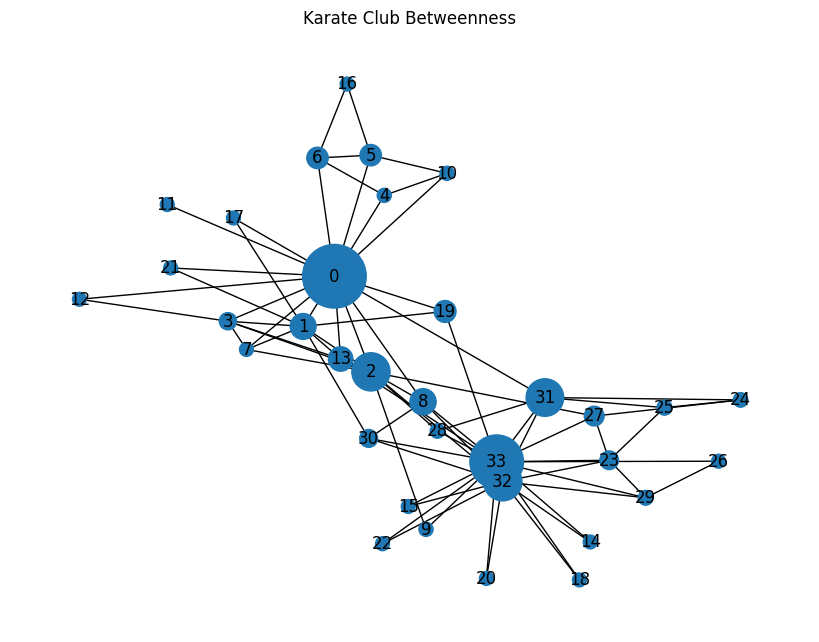

In [25]:
plt.figure(figsize=(8,6))
pos = nx.spring_layout(karate,seed=42)
m = max(K.values())
nx.draw(karate,pos,node_size=[100+2000*K[v]/m for v in karate],with_labels=True)
plt.title("Karate Club Betweenness")
plt.show()

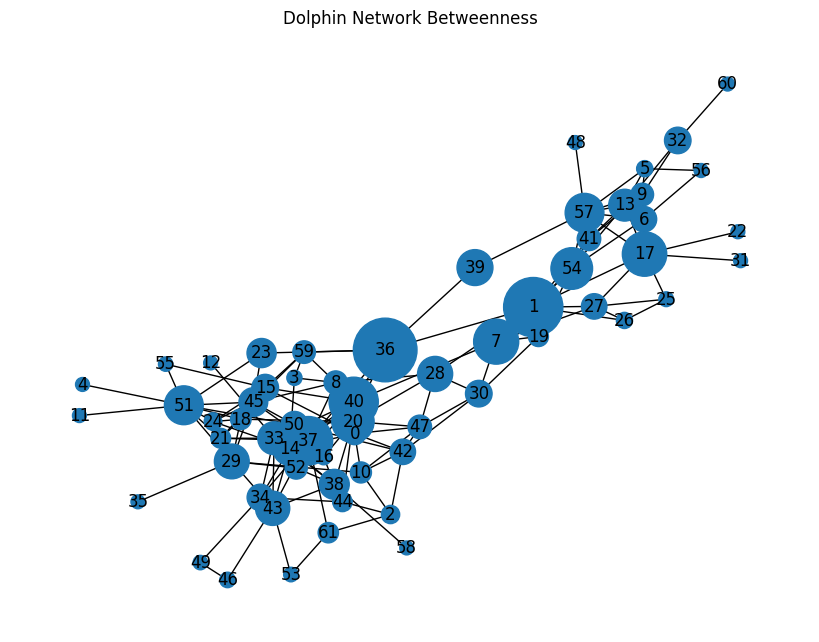

In [26]:
plt.figure(figsize=(8,6))
pos = nx.spring_layout(dolphin,seed=42)
m = max(D.values())
nx.draw(dolphin,pos,node_size=[100+2000*D[v]/m for v in dolphin],with_labels=True)
plt.title("Dolphin Network Betweenness")
plt.show()

In [27]:
Kmax = max(K,key=K.get)
Dmax = max(D,key=D.get)

K2 = karate.copy()
D2 = dolphin.copy()

K2.remove_node(Kmax)
D2.remove_node(Dmax)

print("\nKarate:",nx.number_connected_components(karate),len(max(nx.connected_components(karate),key=len)),"->",nx.number_connected_components(K2),len(max(nx.connected_components(K2),key=len)))

print("Dolphin:",nx.number_connected_components(dolphin),len(max(nx.connected_components(dolphin),key=len)),"->",nx.number_connected_components(D2),len(max(nx.connected_components(D2),key=len)))

print("Most critical Karate node:",Kmax)
print("Most critical Dolphin node:",Dmax)


Karate: 1 34 -> 3 27
Dolphin: 1 62 -> 1 61
Most critical Karate node: 0
Most critical Dolphin node: 36


Q3. Eigenvector Centrality: Identifying Influential Individuals Using Zachary’s Karate Club and the Dolphin Social Network datasets, calculate the eigenvector centrality of every node and identify the top 5 nodes with the highest values. Compare the rankings across both networks and visualize each network with node sizes proportional to eigenvector centrality. Compare the node with the highest eigenvector centrality with the node having the highest degree centrality, and determine whether having many connections always results in strong influence. Based on the network structure, explain how connections to highly influential individuals affect the importance of a node.

In [28]:
def eigenvector(G):
    score = {v:1 for v in G}
    for i in range(50):
        new = {v:sum(score[u] for u in G[v]) for v in G}
        length = sum(x*x for x in new.values())**0.5
        score = {v:new[v]/length for v in G}
    return score

In [29]:
K_eigen = eigenvector(karate)
D_eigen = eigenvector(dolphin)

In [30]:
print("\nKarate Top 5:")
for v in sorted(K_eigen,key=K_eigen.get,reverse=True)[:5]:
    print(v,round(K_eigen[v],4))

print("\nDolphin Top 5:")
for v in sorted(D_eigen,key=D_eigen.get,reverse=True)[:5]:
    print(v,round(D_eigen[v],4))


Karate Top 5:
33 0.3734
0 0.3555
2 0.3172
32 0.3086
1 0.266

Dolphin Top 5:
14 0.3158
37 0.3006
45 0.285
33 0.2811
50 0.2177


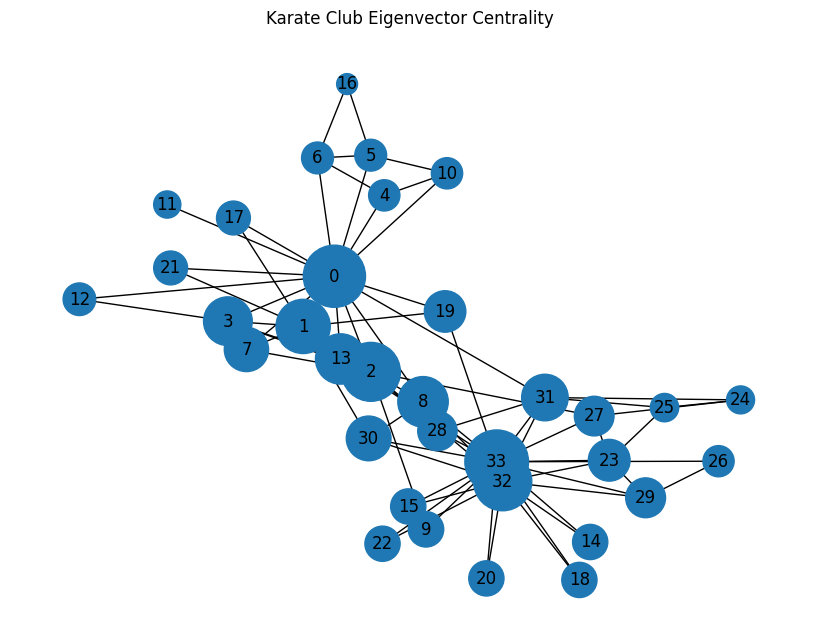

In [31]:
plt.figure(figsize=(8,6))
pos = nx.spring_layout(karate,seed=42)
m = max(K_eigen.values())
nx.draw(karate,pos,node_size=[100+2000*K_eigen[v]/m for v in karate],with_labels=True)
plt.title("Karate Club Eigenvector Centrality")
plt.show()

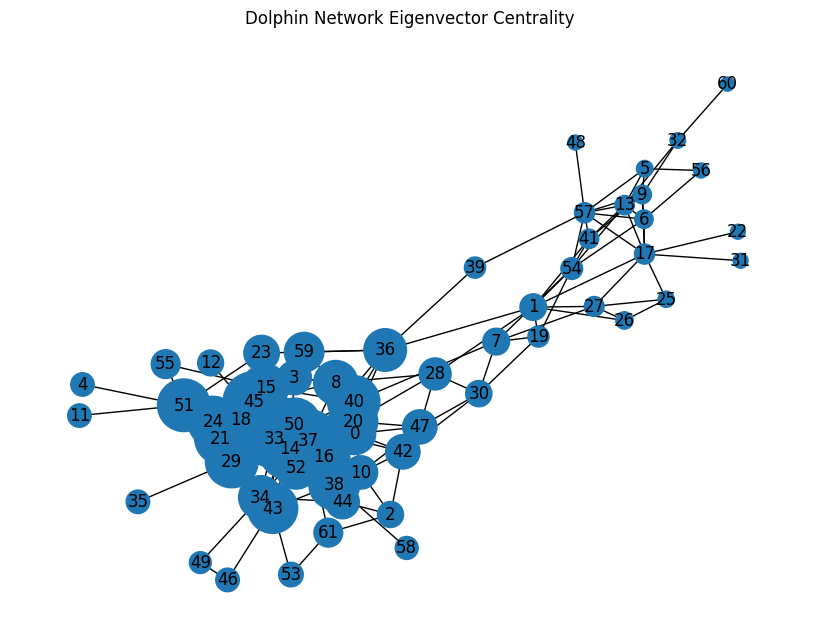

In [32]:
plt.figure(figsize=(8,6))
pos = nx.spring_layout(dolphin,seed=42)
m = max(D_eigen.values())
nx.draw(dolphin,pos,node_size=[100+2000*D_eigen[v]/m for v in dolphin],with_labels=True)
plt.title("Dolphin Network Eigenvector Centrality")
plt.show()

In [33]:
K_degree = {v:len(list(karate.neighbors(v))) for v in karate}
D_degree = {v:len(list(dolphin.neighbors(v))) for v in dolphin}

print("\nKarate highest degree:",max(K_degree,key=K_degree.get))
print("Karate highest eigenvector:",max(K_eigen,key=K_eigen.get))

print("\nDolphin highest degree:",max(D_degree,key=D_degree.get))
print("Dolphin highest eigenvector:",max(D_eigen,key=D_eigen.get))


Karate highest degree: 33
Karate highest eigenvector: 33

Dolphin highest degree: 14
Dolphin highest eigenvector: 14
